# 🏎️ Formula 1 Race Data Analysis

## Overview
This notebook provides comprehensive analysis of Formula 1 race data including:
- 📊 Lap time performance trends
- 🛞 Tire compound performance analysis  
- 👨‍✈️ Driver performance comparison
- 📈 Statistical insights and visualizations

**Data Source:** FastF1 API via `get_data.py` script

---

In [3]:
## 1. Import Libraries and Setup

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

print("✅ Libraries imported successfully")
print("📊 Visualization settings configured")

✅ Libraries imported successfully
📊 Visualization settings configured


## 2. Load and Explore Data

**Instructions:**
- **Option A**: Run the cell below for interactive file selection (you'll choose from a list)
- **Option B**: Run the second cell to auto-select the most recent file
- Choose **only one option** and run the corresponding cell

### Option A: Interactive File Selection (Run this cell for interactive mode)

In [5]:
# File selection with user input
import os
import glob

# Get all CSV files in the current directory
csv_files = glob.glob('*_laps_clean.csv')

if not csv_files:
    print("❌ No data files found!")
    print("💡 Please run 'get_data.py' first to generate data files.")
else:
    print("📁 Available data files:")
    print("="*60)
    for i, file in enumerate(csv_files, 1):
        # Parse filename to extract info
        parts = file.replace('_laps_clean.csv', '').split('_')
        if len(parts) >= 3:
            year = parts[0]
            session = parts[-1]
            track = '_'.join(parts[1:-1])
            print(f"  {i}. {year} {track} - Session: {session}")
        else:
            print(f"  {i}. {file}")
    print("="*60)
    
    # Get user selection
    try:
        selection = int(input(f"\nSelect file number (1-{len(csv_files)}): "))
        if 1 <= selection <= len(csv_files):
            FILE_NAME = csv_files[selection - 1]
            print(f"\n✅ Selected: {FILE_NAME}")
        else:
            print(f"⚠️ Invalid selection. Using first file: {csv_files[0]}")
            FILE_NAME = csv_files[0]
    except (ValueError, EOFError):
        print(f"⚠️ No input provided. Using first file: {csv_files[0]}")
        FILE_NAME = csv_files[0]

# Load the selected data file
try:
    df = pd.read_csv(FILE_NAME)
    
    # Display data summary
    print(f"\n{'='*60}")
    print("📋 DATA SUMMARY")
    print(f"{'='*60}")
    print(f"File: {FILE_NAME}")
    print(f"Total laps recorded: {len(df):,}")
    print(f"Number of drivers: {df['Driver'].nunique()}")
    print(f"Drivers: {', '.join(sorted(df['Driver'].unique()))}")
    print(f"Tire compounds used: {', '.join(sorted(df['Compound'].unique()))}")
    print(f"Lap time range: {df['LapTime'].min():.3f}s - {df['LapTime'].max():.3f}s")
    print(f"Average lap time: {df['LapTime'].mean():.3f}s")
    print(f"{'='*60}\n")
    
    # Display first few rows
    print("📊 First 5 rows of data:")
    display(df.head())
    
    # Display data types and missing values
    print("\n📈 Data Info:")
    print(df.info())
    
except FileNotFoundError:
    print(f"❌ Error: File '{FILE_NAME}' not found.")
    print("💡 Please run 'get_data.py' first to generate the data file.")
except Exception as e:
    print(f"❌ Error loading data: {e}")

📁 Available data files:
  1. 2023 Bahrain - Session: R
  2. 2020 Turkey - Session: R
  3. 2021 Abu_Dhabi - Session: R

✅ Selected: 2020_Turkey_R_laps_clean.csv

📋 DATA SUMMARY
File: 2020_Turkey_R_laps_clean.csv
Total laps recorded: 1,075
Number of drivers: 20
Drivers: ALB, BOT, GAS, GIO, GRO, HAM, KVY, LAT, LEC, MAG, NOR, OCO, PER, RAI, RIC, RUS, SAI, STR, VER, VET
Tire compounds used: INTERMEDIATE, WET
Lap time range: 96.806s - 158.785s
Average lap time: 108.042s

📊 First 5 rows of data:


,Driver,LapNumber,LapTime,Compound,Stint,TyreLife
0,GAS,1.0,140.954,WET,1.0,5
1,GAS,2.0,124.663,WET,1.0,6
2,GAS,3.0,121.401,WET,1.0,7
3,GAS,4.0,120.133,WET,1.0,8
4,GAS,5.0,118.285,WET,1.0,9



📈 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1075 entries, 0 to 1074
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Driver     1075 non-null   object 
 1   LapNumber  1075 non-null   float64
 2   LapTime    1075 non-null   float64
 3   Compound   1075 non-null   object 
 4   Stint      1075 non-null   float64
 5   TyreLife   1075 non-null   int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 50.5+ KB
None


### Option B: Direct File Selection (Alternative - no input needed)

In [6]:
# Alternative: Direct file selection (uncomment and modify as needed)
# FILE_NAME = '2023_Bahrain_R_laps_clean.csv'  # Specify your file directly

# Or use the most recent file automatically
import os
import glob

csv_files = glob.glob('*_laps_clean.csv')

if csv_files:
    # Sort by modification time (most recent first)
    csv_files.sort(key=os.path.getmtime, reverse=True)
    FILE_NAME = csv_files[0]
    print(f"📁 Auto-selected most recent file: {FILE_NAME}")
    
    # Load the data
    try:
        df = pd.read_csv(FILE_NAME)
        print(f"✅ Successfully loaded: {FILE_NAME}")
        print(f"📊 Total laps: {len(df):,} | Drivers: {df['Driver'].nunique()}")
        display(df.head())
    except Exception as e:
        print(f"❌ Error loading data: {e}")
else:
    print("❌ No data files found! Please run 'get_data.py' first.")

📁 Auto-selected most recent file: 2021_Abu_Dhabi_R_laps_clean.csv
✅ Successfully loaded: 2021_Abu_Dhabi_R_laps_clean.csv
📊 Total laps: 989 | Drivers: 19


,Driver,LapNumber,LapTime,Compound,Stint,TyreLife
0,GAS,1.0,99.330,HARD,1.0,1
1,GAS,2.0,92.814,HARD,1.0,2
2,GAS,3.0,91.533,HARD,1.0,3
3,GAS,4.0,91.439,HARD,1.0,4
4,GAS,5.0,91.367,HARD,1.0,5


## 3. Tire Performance Analysis

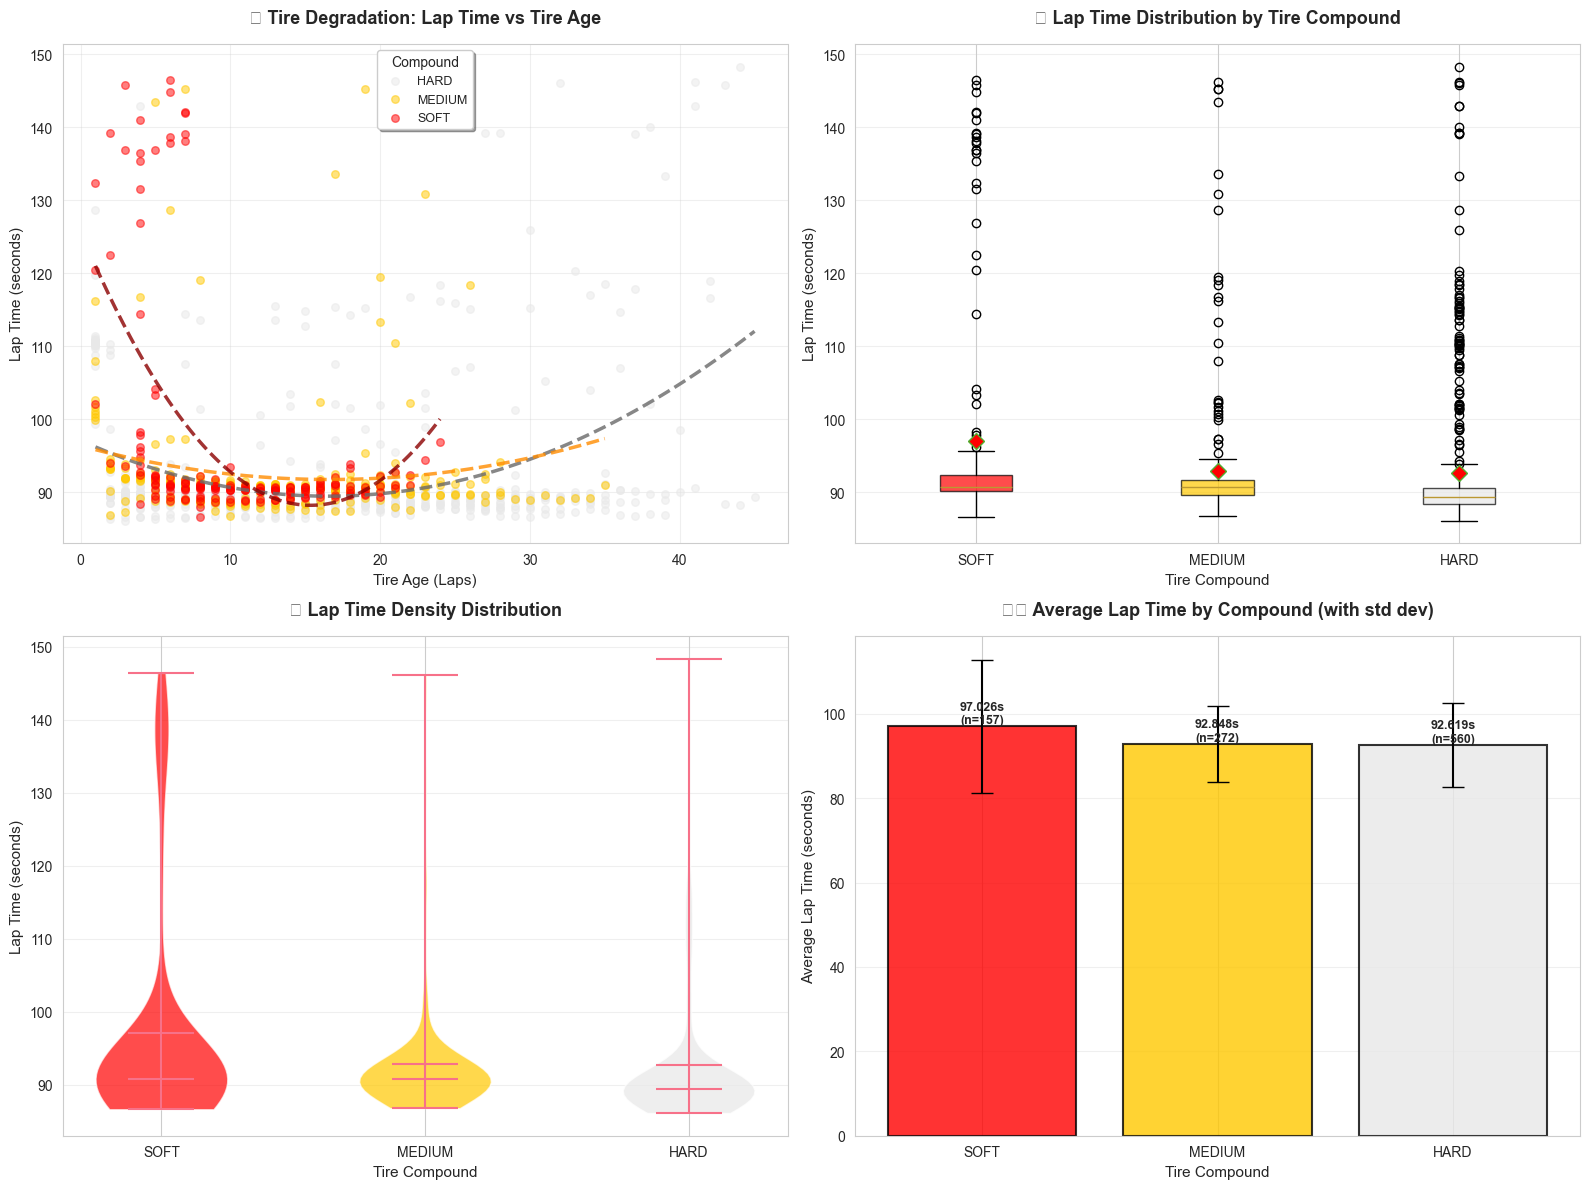


📊 TIRE COMPOUND STATISTICS
            Mean     Std  Count
Compound                       
SOFT      97.026  15.701    157
MEDIUM    92.848   9.003    272
HARD      92.619  10.049    560


In [7]:
# Tire degradation analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define tire compound colors
TIRE_COLORS = {'SOFT': '#FF0000', 'MEDIUM': '#FFC800', 'HARD': '#E8E8E8'}
TIRE_DARK_COLORS = {'SOFT': '#8B0000', 'MEDIUM': '#FF8C00', 'HARD': '#696969'}

# 1. Scatter plot: Tire age vs Lap time by compound
ax1 = axes[0, 0]
for compound in sorted(df['Compound'].unique()):
    compound_data = df[df['Compound'] == compound]
    ax1.scatter(compound_data['TyreLife'], compound_data['LapTime'], 
               label=compound, alpha=0.5, s=30, color=TIRE_COLORS.get(compound, 'gray'))
    
    # Add trend line
    if len(compound_data) > 1:
        z = np.polyfit(compound_data['TyreLife'], compound_data['LapTime'], 2)
        p = np.poly1d(z)
        x_range = np.linspace(compound_data['TyreLife'].min(), 
                             compound_data['TyreLife'].max(), 100)
        ax1.plot(x_range, p(x_range), '--', linewidth=2.5, 
                color=TIRE_DARK_COLORS.get(compound, 'black'), alpha=0.8)

ax1.set_title('🛞 Tire Degradation: Lap Time vs Tire Age', fontweight='bold', pad=15)
ax1.set_xlabel('Tire Age (Laps)')
ax1.set_ylabel('Lap Time (seconds)')
ax1.legend(title='Compound', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3)

# 2. Box plot: Lap time distribution by compound
ax2 = axes[0, 1]
compound_order = ['SOFT', 'MEDIUM', 'HARD'] if 'HARD' in df['Compound'].unique() else sorted(df['Compound'].unique())
box_plot = ax2.boxplot([df[df['Compound'] == c]['LapTime'].values for c in compound_order],
                        labels=compound_order, patch_artist=True, showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, compound in zip(box_plot['boxes'], compound_order):
    patch.set_facecolor(TIRE_COLORS.get(compound, 'gray'))
    patch.set_alpha(0.7)

ax2.set_title('📊 Lap Time Distribution by Tire Compound', fontweight='bold', pad=15)
ax2.set_xlabel('Tire Compound')
ax2.set_ylabel('Lap Time (seconds)')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Violin plot: Density distribution
ax3 = axes[1, 0]
parts = ax3.violinplot([df[df['Compound'] == c]['LapTime'].values for c in compound_order],
                       positions=range(len(compound_order)), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(TIRE_COLORS.get(compound_order[i], 'gray'))
    pc.set_alpha(0.7)

ax3.set_xticks(range(len(compound_order)))
ax3.set_xticklabels(compound_order)
ax3.set_title('🎻 Lap Time Density Distribution', fontweight='bold', pad=15)
ax3.set_xlabel('Tire Compound')
ax3.set_ylabel('Lap Time (seconds)')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Average lap time comparison
ax4 = axes[1, 1]
compound_stats = df.groupby('Compound').agg({
    'LapTime': ['mean', 'std', 'count']
}).round(3)
compound_stats.columns = ['Mean', 'Std', 'Count']
compound_stats = compound_stats.reindex(compound_order)

bars = ax4.bar(range(len(compound_stats)), compound_stats['Mean'], 
              yerr=compound_stats['Std'], capsize=8, alpha=0.8,
              color=[TIRE_COLORS.get(c, 'gray') for c in compound_stats.index],
              edgecolor='black', linewidth=1.5)

ax4.set_xticks(range(len(compound_stats)))
ax4.set_xticklabels(compound_stats.index)
ax4.set_title('⏱️ Average Lap Time by Compound (with std dev)', fontweight='bold', pad=15)
ax4.set_xlabel('Tire Compound')
ax4.set_ylabel('Average Lap Time (seconds)')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}s\n(n={int(compound_stats.iloc[i]["Count"])})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistical summary
print("\n📊 TIRE COMPOUND STATISTICS")
print("="*60)
print(compound_stats)
print("="*60)

## 4. Driver Performance Analysis

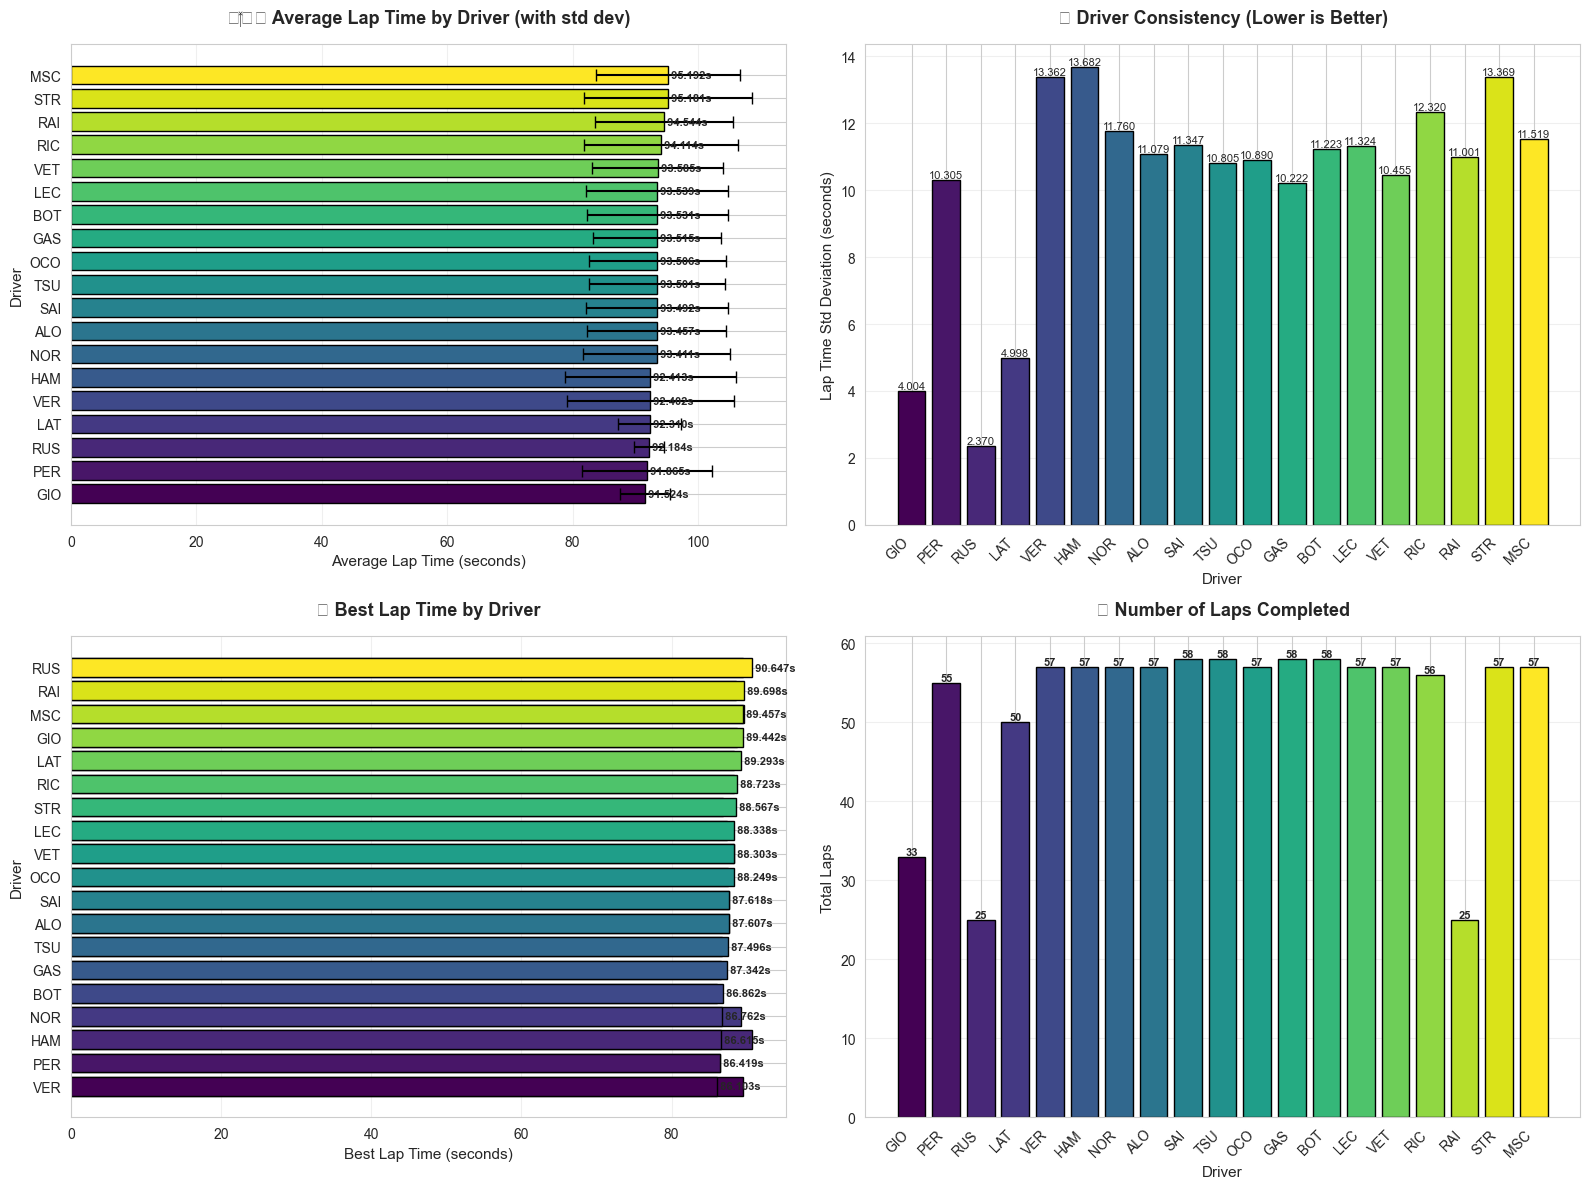


👨‍✈️ DRIVER PERFORMANCE STATISTICS
          Mean     Std    Best  Laps
Driver                              
GIO     91.524   4.004  89.442    33
PER     91.865  10.305  86.419    55
RUS     92.184   2.370  90.647    25
LAT     92.310   4.998  89.293    50
VER     92.402  13.362  86.103    57
HAM     92.413  13.682  86.615    57
NOR     93.411  11.760  86.762    57
ALO     93.457  11.079  87.607    57
SAI     93.492  11.347  87.618    58
TSU     93.501  10.805  87.496    58
OCO     93.506  10.890  88.249    57
GAS     93.515  10.222  87.342    58
BOT     93.531  11.223  86.862    58
LEC     93.539  11.324  88.338    57
VET     93.585  10.455  88.303    57
RIC     94.114  12.320  88.723    56
RAI     94.544  11.001  89.698    25
STR     95.181  13.369  88.567    57
MSC     95.192  11.519  89.457    57


In [8]:
# Driver performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate driver statistics
driver_stats = df.groupby('Driver').agg({
    'LapTime': ['mean', 'std', 'min', 'count']
}).round(3)
driver_stats.columns = ['Mean', 'Std', 'Best', 'Laps']
driver_stats = driver_stats.sort_values('Mean')

# 1. Average lap times by driver
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(driver_stats)))
bars = ax1.barh(range(len(driver_stats)), driver_stats['Mean'], 
               xerr=driver_stats['Std'], capsize=4, color=colors, 
               edgecolor='black', linewidth=1)

ax1.set_yticks(range(len(driver_stats)))
ax1.set_yticklabels(driver_stats.index)
ax1.set_title('👨‍✈️ Average Lap Time by Driver (with std dev)', fontweight='bold', pad=15)
ax1.set_xlabel('Average Lap Time (seconds)')
ax1.set_ylabel('Driver')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(driver_stats.iterrows()):
    ax1.text(row['Mean'], i, f" {row['Mean']:.3f}s ", 
            va='center', fontsize=8, fontweight='bold')

# 2. Lap time consistency (std deviation)
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(driver_stats)), driver_stats['Std'], 
               color=colors, edgecolor='black', linewidth=1)

ax2.set_xticks(range(len(driver_stats)))
ax2.set_xticklabels(driver_stats.index, rotation=45, ha='right')
ax2.set_title('📊 Driver Consistency (Lower is Better)', fontweight='bold', pad=15)
ax2.set_xlabel('Driver')
ax2.set_ylabel('Lap Time Std Deviation (seconds)')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 3. Best lap times
ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(driver_stats)), driver_stats['Best'], 
                color=colors, edgecolor='black', linewidth=1)

ax3.set_yticks(range(len(driver_stats)))
ax3.set_yticklabels(driver_stats.sort_values('Best').index)
driver_stats_by_best = driver_stats.sort_values('Best')

bars3_sorted = ax3.barh(range(len(driver_stats_by_best)), driver_stats_by_best['Best'], 
                       color=colors, edgecolor='black', linewidth=1)

ax3.set_title('🏆 Best Lap Time by Driver', fontweight='bold', pad=15)
ax3.set_xlabel('Best Lap Time (seconds)')
ax3.set_ylabel('Driver')
ax3.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(driver_stats_by_best.iterrows()):
    ax3.text(row['Best'], i, f" {row['Best']:.3f}s ", 
            va='center', fontsize=8, fontweight='bold')

# 4. Lap count by driver
ax4 = axes[1, 1]
bars4 = ax4.bar(range(len(driver_stats)), driver_stats['Laps'], 
               color=colors, edgecolor='black', linewidth=1)

ax4.set_xticks(range(len(driver_stats)))
ax4.set_xticklabels(driver_stats.index, rotation=45, ha='right')
ax4.set_title('📈 Number of Laps Completed', fontweight='bold', pad=15)
ax4.set_xlabel('Driver')
ax4.set_ylabel('Total Laps')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n👨‍✈️ DRIVER PERFORMANCE STATISTICS")
print("="*80)
print(driver_stats.to_string())
print("="*80)

## 5. Driver vs Tire Performance

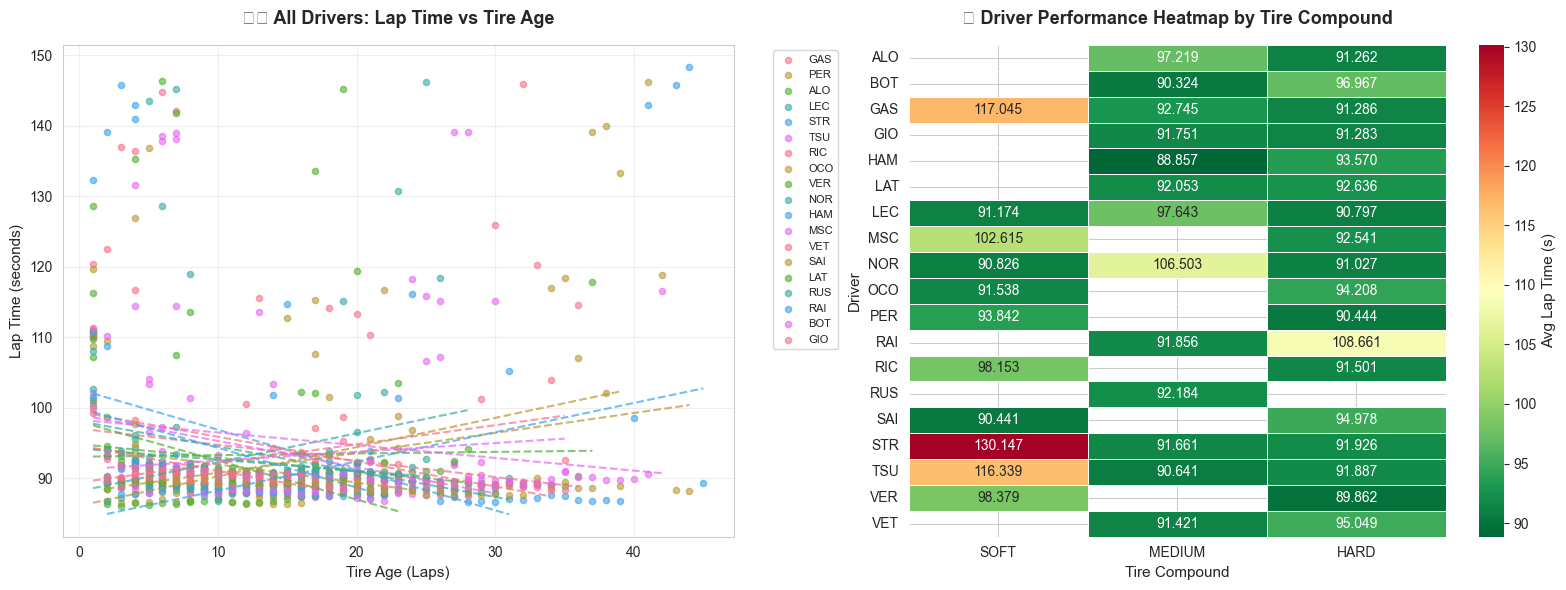


🏆 TOP 5 DRIVERS BY TIRE COMPOUND

HARD Compound:
  1. VER: 89.862s
  2. PER: 90.444s
  3. LEC: 90.797s
  4. NOR: 91.027s
  5. ALO: 91.262s

MEDIUM Compound:
  1. HAM: 88.857s
  2. BOT: 90.324s
  3. TSU: 90.641s
  4. VET: 91.421s
  5. STR: 91.661s

SOFT Compound:
  1. SAI: 90.441s
  2. NOR: 90.826s
  3. LEC: 91.174s
  4. OCO: 91.538s
  5. PER: 93.842s


In [9]:
# Combined driver and tire analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Lap time progression for all drivers
ax1 = axes[0]
for driver in df['Driver'].unique():
    driver_data = df[df['Driver'] == driver].sort_values('TyreLife')
    ax1.scatter(driver_data['TyreLife'], driver_data['LapTime'], 
               label=driver, alpha=0.6, s=20)
    
    # Add trend line for each driver
    if len(driver_data) > 3:
        z = np.polyfit(driver_data['TyreLife'], driver_data['LapTime'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(driver_data['TyreLife'].min(), 
                             driver_data['TyreLife'].max(), 50)
        ax1.plot(x_trend, p(x_trend), '--', alpha=0.7, linewidth=1.5)

ax1.set_title('🏎️ All Drivers: Lap Time vs Tire Age', fontweight='bold', pad=15)
ax1.set_xlabel('Tire Age (Laps)')
ax1.set_ylabel('Lap Time (seconds)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Heatmap: Average lap time by driver and compound
ax2 = axes[1]
pivot_data = df.pivot_table(values='LapTime', index='Driver', 
                            columns='Compound', aggfunc='mean')

# Reorder columns if possible
if all(c in pivot_data.columns for c in ['SOFT', 'MEDIUM', 'HARD']):
    pivot_data = pivot_data[['SOFT', 'MEDIUM', 'HARD']]

sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn_r', 
           linewidths=0.5, cbar_kws={'label': 'Avg Lap Time (s)'}, ax=ax2)

ax2.set_title('🔥 Driver Performance Heatmap by Tire Compound', fontweight='bold', pad=15)
ax2.set_xlabel('Tire Compound')
ax2.set_ylabel('Driver')

plt.tight_layout()
plt.show()

# Print top 5 drivers by tire compound
print("\n🏆 TOP 5 DRIVERS BY TIRE COMPOUND")
print("="*60)
for compound in sorted(df['Compound'].unique()):
    print(f"\n{compound} Compound:")
    compound_leaders = df[df['Compound'] == compound].groupby('Driver')['LapTime'].mean().sort_values().head(5)
    for i, (driver, time) in enumerate(compound_leaders.items(), 1):
        print(f"  {i}. {driver}: {time:.3f}s")
print("="*60)

## 6. Statistical Insights & Summary

In [10]:
# Generate comprehensive statistical summary
print("📊 COMPREHENSIVE RACE ANALYSIS SUMMARY")
print("="*80)

# Overall statistics
print("\n1️⃣ OVERALL RACE STATISTICS:")
print("-" * 80)
print(f"Total laps analyzed: {len(df):,}")
print(f"Average lap time: {df['LapTime'].mean():.3f}s (±{df['LapTime'].std():.3f}s)")
print(f"Fastest lap: {df['LapTime'].min():.3f}s")
print(f"Slowest lap: {df['LapTime'].max():.3f}s")
print(f"Median lap time: {df['LapTime'].median():.3f}s")

# Tire compound analysis
print("\n2️⃣ TIRE COMPOUND PERFORMANCE:")
print("-" * 80)
for compound in sorted(df['Compound'].unique()):
    compound_data = df[df['Compound'] == compound]['LapTime']
    print(f"\n{compound}:")
    print(f"  • Average: {compound_data.mean():.3f}s")
    print(f"  • Best: {compound_data.min():.3f}s")
    print(f"  • Consistency (std): {compound_data.std():.3f}s")
    print(f"  • Total laps: {len(compound_data)}")

# Driver rankings
print("\n3️⃣ DRIVER RANKINGS:")
print("-" * 80)
driver_ranking = df.groupby('Driver').agg({
    'LapTime': ['mean', 'min', 'count']
}).round(3)
driver_ranking.columns = ['Avg Time', 'Best Time', 'Laps']
driver_ranking = driver_ranking.sort_values('Avg Time')

print("\nBy Average Lap Time:")
for i, (driver, data) in enumerate(driver_ranking.iterrows(), 1):
    print(f"  {i:2d}. {driver:20s} - Avg: {data['Avg Time']:.3f}s | Best: {data['Best Time']:.3f}s | Laps: {int(data['Laps'])}")

# Correlation analysis
print("\n4️⃣ CORRELATION ANALYSIS:")
print("-" * 80)
correlation = df[['TyreLife', 'LapTime']].corr().iloc[0, 1]
print(f"Tire Age vs Lap Time correlation: {correlation:.3f}")
if correlation > 0.5:
    print("  ✅ Strong positive correlation - lap times increase with tire age")
elif correlation > 0.2:
    print("  ⚠️ Moderate positive correlation - some tire degradation effect")
else:
    print("  ℹ️ Weak correlation - minimal tire degradation effect")

# Key insights
print("\n5️⃣ KEY INSIGHTS:")
print("-" * 80)

# Fastest driver                                 
fastest_driver = driver_ranking.iloc[0]
print(f"🏆 Fastest driver: {driver_ranking.index[0]} ({fastest_driver['Avg Time']:.3f}s avg)")

# Best tire compound
best_compound = df.groupby('Compound')['LapTime'].mean().idxmin()
best_compound_time = df.groupby('Compound')['LapTime'].mean().min()
print(f"🛞 Best tire compound: {best_compound} ({best_compound_time:.3f}s avg)")

# Most consistent driver
most_consistent = df.groupby('Driver')['LapTime'].std().idxmin()
consistency_std = df.groupby('Driver')['LapTime'].std().min()
print(f"📊 Most consistent driver: {most_consistent} (std: {consistency_std:.3f}s)")

# Tire degradation rate
avg_degradation = df.groupby('TyreLife')['LapTime'].mean()
if len(avg_degradation) > 1:
    degradation_rate = (avg_degradation.iloc[-1] - avg_degradation.iloc[0]) / len(avg_degradation)
    print(f"📉 Average tire degradation rate: {degradation_rate:.4f}s per lap")

print("\n" + "="*80)
print("✅ Analysis complete!")

📊 COMPREHENSIVE RACE ANALYSIS SUMMARY

1️⃣ OVERALL RACE STATISTICS:
--------------------------------------------------------------------------------
Total laps analyzed: 989
Average lap time: 93.381s (±10.991s)
Fastest lap: 86.103s
Slowest lap: 148.331s
Median lap time: 89.997s

2️⃣ TIRE COMPOUND PERFORMANCE:
--------------------------------------------------------------------------------

HARD:
  • Average: 92.619s
  • Best: 86.103s
  • Consistency (std): 10.049s
  • Total laps: 560

MEDIUM:
  • Average: 92.848s
  • Best: 86.762s
  • Consistency (std): 9.003s
  • Total laps: 272

SOFT:
  • Average: 97.026s
  • Best: 86.618s
  • Consistency (std): 15.701s
  • Total laps: 157

3️⃣ DRIVER RANKINGS:
--------------------------------------------------------------------------------

By Average Lap Time:
   1. GIO                  - Avg: 91.524s | Best: 89.442s | Laps: 33
   2. PER                  - Avg: 91.865s | Best: 86.419s | Laps: 55
   3. RUS                  - Avg: 92.184s | Best: 90.

---
## 🏎️ 7. Feature Engineering for Machine Learning Model

### 🎯 Objective
Build a **predictive model** to estimate F1 lap times based on race conditions and tire performance.

### 📊 Machine Learning Pipeline

This section implements a complete ML preparation workflow:

#### **Phase 1: Feature Selection** 
- Select relevant racing variables that influence lap performance
- Identify numerical and categorical features
- Define prediction target (Lap Time)

#### **Phase 2: Data Encoding**
- Convert categorical variables (tire compounds) to numerical format
- Apply **One-Hot Encoding** for multi-class features
- Ensure all inputs are ML-compatible

#### **Phase 3: Final Preparation**
- Create feature matrix **X** (inputs)
- Create target vector **y** (output to predict)
- Validate data quality and readiness

---

### 🔑 Key Features for Lap Time Prediction

| Feature | Type | Description | Impact on Lap Time |
|---------|------|-------------|-------------------|
| **LapNumber** | Numerical | Current lap in race | Fuel load decreases → faster laps |
| **Stint** | Numerical | Strategy phase | Different tire compounds per stint |
| **TyreLife** | Numerical | Laps on current tires | Degradation → slower laps |
| **Compound** | Categorical | Tire type (SOFT/MEDIUM/HARD) | Performance vs. durability trade-off |

---

### 📈 Why This Matters

Understanding which factors most influence lap times helps:
- **Race Strategy**: Optimize pit stop timing
- **Tire Management**: Balance speed vs. tire life
- **Performance Analysis**: Identify driver/team strengths
- **Predictive Modeling**: Forecast race outcomes

---

In [ ]:
# =============================================================================
# 8. FEATURE SELECTION & DATA PREPARATION
# =============================================================================
# Goal: Prepare race data for predictive modeling
# Target: Predict lap times based on racing conditions
# =============================================================================

if 'df' not in locals():
    print("❌ ERROR: DataFrame 'df' not found!")
    print("   Please run the data loading cells first.\n")
else:
    # Define prediction target
    target = 'LapTime'
    
    # Select racing features that impact lap performance
    features = [
        'LapNumber',    # Race progression (fuel load, tire wear)
        'Stint',        # Strategy phase (different tire compounds/age)
        'TyreLife',     # Tire degradation indicator
        'Compound'      # Tire type (SOFT, MEDIUM, HARD, INTERMEDIATE, WET)
    ]
    
    # Create model dataset
    model_data = df[features + [target]].copy()
    
    # Display summary
    print("🏁 " + "="*68)
    print("   FEATURE ENGINEERING - LAP TIME PREDICTION MODEL")
    print("="*71)
    print(f"\n🎯 Target Variable: {target}")
    print(f"📊 Features Selected: {len(features)}")
    for i, feat in enumerate(features, 1):
        print(f"   {i}. {feat}")
    
    print(f"\n? Dataset Shape: {model_data.shape[0]:,} laps × {model_data.shape[1]} columns")
    print("\n" + "="*71)
    
    print("\n📋 Sample Data (First 5 Laps):")
    display(model_data.head())
    
    print("\n📊 Missing Values Check:")
    missing = model_data.isnull().sum()
    if missing.sum() == 0:
        print("   ✅ No missing values detected")
    else:
        print(missing[missing > 0])

✅ Selected features and target variable.
Features: ['LapNumber', 'Stint', 'TyreLife', 'Compound']
Target: LapTime

📊 Data for the model (first 5 rows):


,LapNumber,Stint,TyreLife,Compound,LapTime
0,1.0,1.0,1,HARD,99.330
1,2.0,1.0,2,HARD,92.814
2,3.0,1.0,3,HARD,91.533
3,4.0,1.0,4,HARD,91.439
4,5.0,1.0,5,HARD,91.367


In [ ]:
# =============================================================================
# 9. CATEGORICAL ENCODING - TIRE COMPOUNDS
# =============================================================================
# Convert tire compound types to numerical format using One-Hot Encoding
# Each compound gets its own binary column (0 or 1)
# =============================================================================

print("🏁 " + "="*68)
print("   TIRE COMPOUND ENCODING")
print("="*71)

# Display original compound distribution
print("\n🔧 Original Tire Compound Distribution:")
compound_counts = model_data['Compound'].value_counts()
print(compound_counts)

print("\n📊 Compound Percentages:")
compound_pct = (compound_counts / len(model_data) * 100).round(2)
for compound, pct in compound_pct.items():
    print(f"   {compound:12s}: {pct:6.2f}%  {'█' * int(pct/2)}")

# One-Hot Encoding
print("\n🔄 Applying One-Hot Encoding...")
compound_dummies = pd.get_dummies(model_data['Compound'], prefix='Compound', dtype=int)

# Combine encoded features with original data
model_data_encoded = pd.concat([
    model_data.drop('Compound', axis=1), 
    compound_dummies
], axis=1)

print(f"✅ Created {len(compound_dummies.columns)} binary columns:")
for col in compound_dummies.columns:
    print(f"   • {col}")

print("\n" + "="*71)
print("\n? Encoded Data Sample (First 5 Rows):")
display(model_data_encoded.head())

print("\n📈 Final Data Types:")
print(model_data_encoded.dtypes)

print(f"\n✅ All features are now numeric and ready for ML modeling!")
print("="*71)

Original 'Compound' column:
Compound
HARD      560
MEDIUM    272
SOFT      157
Name: count, dtype: int64

✅ Converted 'Compound' to numeric columns using One-Hot Encoding.
📊 Encoded data (first 5 rows):


,LapNumber,Stint,TyreLife,LapTime,Compound_HARD,Compound_MEDIUM,Compound_SOFT
0,1.0,1.0,1,99.330,1,0,0
1,2.0,1.0,2,92.814,1,0,0
2,3.0,1.0,3,91.533,1,0,0
3,4.0,1.0,4,91.439,1,0,0
4,5.0,1.0,5,91.367,1,0,0



📈 Data types after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   LapNumber        989 non-null    float64
 1   Stint            989 non-null    float64
 2   TyreLife         989 non-null    int64  
 3   LapTime          989 non-null    float64
 4   Compound_HARD    989 non-null    int64  
 5   Compound_MEDIUM  989 non-null    int64  
 6   Compound_SOFT    989 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 54.2 KB
None


In [ ]:
# =============================================================================
# 10. TRAIN-TEST SPLIT PREPARATION
# =============================================================================
# Separate features (X) and target (y) for model training
# X = Input features (what the model uses to make predictions)
# y = Target variable (what the model tries to predict)
# =============================================================================

print("🏁 " + "="*68)
print("   FINALIZING FEATURE MATRIX & TARGET VECTOR")
print("="*71)

# Separate features from target
X = model_data_encoded.drop(target, axis=1)  # All columns except LapTime
y = model_data_encoded[target]                # Only LapTime column

print("\n✅ Feature Matrix (X) and Target Vector (y) Created!")

print("\n" + "-"*71)
print("📊 FEATURE MATRIX (X) - Input Variables")
print("-"*71)
print(f"Shape: {X.shape[0]:,} samples × {X.shape[1]} features\n")
print("Features included:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n" + "-"*71)
print("🎯 TARGET VECTOR (y) - Lap Time (seconds)")
print("-"*71)
print(f"Shape: {y.shape[0]:,} samples")
print(f"Mean:  {y.mean():.3f} seconds")
print(f"Std:   {y.std():.3f} seconds")
print(f"Min:   {y.min():.3f} seconds")
print(f"Max:   {y.max():.3f} seconds")

print("\n" + "="*71)
print("\n📋 Sample Preview:")
print("-"*71)
print("Features (X) - First 5 rows:")
display(X.head())

print("\nTarget (y) - First 5 values:")
display(y.head())

print("\n" + "="*71)
print("✅ Data is ready for Machine Learning!")
print("   Next steps: Train-Test Split → Model Training → Evaluation")
print("="*71)

✅ Final feature matrix (X) and target vector (y) created.

Features (X) - first 5 rows:


,LapNumber,Stint,TyreLife,Compound_HARD,Compound_MEDIUM,Compound_SOFT
0,1.0,1.0,1,1,0,0
1,2.0,1.0,2,1,0,0
2,3.0,1.0,3,1,0,0
3,4.0,1.0,4,1,0,0
4,5.0,1.0,5,1,0,0



Target (y) - first 5 values:


0    99.330
1    92.814
2    91.533
3    91.439
4    91.367
Name: LapTime, dtype: float64


Shape of X: (989, 6)
Shape of y: (989,)


---
## 🔬 11. Advanced Feature Engineering (Optional)

### Additional Features to Improve Model Performance

Beyond basic features, we can create **derived features** that capture racing dynamics:

In [ ]:
# =============================================================================
# 11. ADVANCED FEATURE ENGINEERING
# =============================================================================
# Create derived features that capture racing patterns
# =============================================================================

print("🏁 " + "="*68)
print("   ADVANCED FEATURE ENGINEERING")
print("="*71)

# Create a copy for advanced features
X_advanced = X.copy()

# -------------------------------------------------------------------------
# 1. FUEL LOAD PROXY - Race progression indicator
# -------------------------------------------------------------------------
# Later laps = lighter car (fuel consumed) = potentially faster
# Normalize to 0-1 scale
max_lap = model_data['LapNumber'].max()
X_advanced['FuelLoadProxy'] = 1 - (model_data['LapNumber'] / max_lap)

print("\n1️⃣  Fuel Load Proxy")
print("   📊 Simulates decreasing fuel weight during race")
print(f"   Range: 1.0 (start, full tank) → 0.0 (end, empty tank)")

# -------------------------------------------------------------------------
# 2. TIRE DEGRADATION RATE
# -------------------------------------------------------------------------
# How worn are the tires relative to their typical lifespan?
# Higher values = more degraded tires = slower laps
X_advanced['TireDegradation'] = model_data['TyreLife'] / model_data['TyreLife'].max()

print("\n2️⃣  Tire Degradation Rate")
print("   📊 Normalized tire wear (0 = fresh, 1 = maximum age)")
print(f"   Range: {X_advanced['TireDegradation'].min():.3f} → {X_advanced['TireDegradation'].max():.3f}")

# -------------------------------------------------------------------------
# 3. STINT PHASE - Beginning vs End of stint
# -------------------------------------------------------------------------
# Group laps by stint and calculate position within stint
stint_groups = model_data.groupby('Stint')['LapNumber']
X_advanced['StintProgress'] = stint_groups.transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if len(x) > 1 else 0.5
)

print("\n3️⃣  Stint Progress")
print("   📊 Position within current stint (0 = start, 1 = end)")
print(f"   Helps identify: Fresh tire advantage vs. degradation")

# -------------------------------------------------------------------------
# 4. COMPOUND PERFORMANCE INDEX (based on compound type)
# -------------------------------------------------------------------------
# Assign performance scores based on typical compound behavior
compound_performance = {
    'SOFT': 3,      # Fastest but degrades quickly
    'MEDIUM': 2,    # Balanced performance
    'HARD': 1,      # Slowest but most durable
    'INTERMEDIATE': 2,  # Wet conditions
    'WET': 1        # Heavy rain
}

X_advanced['CompoundPerformance'] = model_data['Compound'].map(
    lambda x: compound_performance.get(x, 2)
)

print("\n4️⃣  Compound Performance Index")
print("   📊 Tire speed ranking (1=slowest, 3=fastest)")
for comp, score in sorted(compound_performance.items(), key=lambda x: x[1], reverse=True):
    if comp in model_data['Compound'].unique():
        print(f"   {comp:12s}: {score} {'🔥' * score}")

# -------------------------------------------------------------------------
# 5. INTERACTION FEATURE - TireLife × Compound Performance
# -------------------------------------------------------------------------
# Combines tire age with compound type
X_advanced['TireLife_x_Compound'] = (
    model_data['TyreLife'] * X_advanced['CompoundPerformance']
)

print("\n5️⃣  Tire-Compound Interaction")
print("   📊 Combines tire wear and compound performance")
print(f"   Captures: How different compounds degrade over time")

# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------
print("\n" + "="*71)
print(f"✅ Created {len(X_advanced.columns) - len(X.columns)} new features!")
print(f"\n📊 Feature Count:")
print(f"   • Original features:  {len(X.columns)}")
print(f"   • Advanced features:  {len(X_advanced.columns)}")
print(f"   • Total samples:      {len(X_advanced):,}")

print("\n📋 All Features:")
for i, col in enumerate(X_advanced.columns, 1):
    marker = "🆕" if col not in X.columns else "  "
    print(f"   {marker} {i:2d}. {col}")

print("\n" + "="*71)
print("\n💡 Usage Note:")
print("   • Use 'X' for basic model (faster training)")
print("   • Use 'X_advanced' for improved accuracy (more complex)")
print("="*71)

---
## 📊 12. Feature Correlation Analysis

### Understanding Feature Relationships

Before training a model, let's analyze how features correlate with lap times:

In [ ]:
# =============================================================================
# 12. FEATURE CORRELATION WITH LAP TIME
# =============================================================================
# Analyze which features have the strongest relationship with lap times
# =============================================================================

print("🏁 " + "="*68)
print("   FEATURE CORRELATION ANALYSIS")
print("="*71)

# Combine features with target for correlation analysis
correlation_data = X_advanced.copy()
correlation_data['LapTime'] = y

# Calculate correlation with LapTime
correlations = correlation_data.corr()['LapTime'].drop('LapTime').sort_values(key=abs, ascending=False)

print("\n📊 Feature Correlations with Lap Time")
print("   (Higher absolute value = stronger relationship)\n")
print("-"*71)

for feature, corr in correlations.items():
    # Determine strength
    abs_corr = abs(corr)
    if abs_corr > 0.5:
        strength = "🔴 STRONG"
    elif abs_corr > 0.3:
        strength = "🟡 MODERATE"
    else:
        strength = "🟢 WEAK"
    
    # Determine direction
    direction = "↑ Positive" if corr > 0 else "↓ Negative"
    
    # Create visual bar
    bar_length = int(abs_corr * 50)
    bar = "█" * bar_length
    
    print(f"{feature:25s} {corr:7.4f}  {direction:12s} {strength:12s}")
    print(f"{'':25s} {bar}")

print("\n" + "="*71)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Correlation bar chart
ax1 = axes[0]
colors = ['red' if x > 0 else 'blue' for x in correlations.values]
correlations.plot(kind='barh', ax=ax1, color=colors, alpha=0.7)
ax1.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax1.set_title('🏎️ Feature Correlations with Lap Time', fontsize=14, fontweight='bold', pad=20)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Correlation heatmap (top features only)
ax2 = axes[1]
top_features = correlations.head(8).index.tolist() + ['LapTime']
corr_matrix = correlation_data[top_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax2)
ax2.set_title('🔥 Top Features - Correlation Matrix', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation Guide:")
print("   • Positive correlation: Feature increases → Lap time increases (slower)")
print("   • Negative correlation: Feature increases → Lap time decreases (faster)")
print("   • Strong (|r| > 0.5): Feature is highly predictive of lap time")
print("="*71)

---
## ⚙️ 13. Feature Scaling & Normalization

### Why Scale Features?

Machine learning algorithms perform better when features are on similar scales. Without scaling:
- Features with large ranges dominate the model
- Training is slower and less stable
- Some algorithms (like neural networks) may fail to converge

In [ ]:
# =============================================================================
# 13. FEATURE SCALING
# =============================================================================
# Standardize features to have mean=0 and std=1
# This improves model performance and training speed
# =============================================================================

from sklearn.preprocessing import StandardScaler

print("🏁 " + "="*68)
print("   FEATURE SCALING & NORMALIZATION")
print("="*71)

# Initialize scaler
scaler = StandardScaler()

# Scale basic features
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Scale advanced features
X_advanced_scaled = pd.DataFrame(
    scaler.fit_transform(X_advanced),
    columns=X_advanced.columns,
    index=X_advanced.index
)

print("\n✅ Features scaled using StandardScaler")
print("   Formula: z = (x - μ) / σ")
print("   • μ = mean of feature")
print("   • σ = standard deviation of feature")

# Compare before/after scaling
print("\n" + "-"*71)
print("📊 BEFORE SCALING (Original Features)")
print("-"*71)
print(X.describe().loc[['mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*71)
print("📊 AFTER SCALING (Standardized Features)")
print("-"*71)
print(X_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(3))

print("\n" + "="*71)
print("✅ All features now have:")
print("   • Mean ≈ 0.0")
print("   • Standard Deviation ≈ 1.0")
print("   • Comparable scales for optimal ML performance")
print("="*71)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before scaling
ax1 = axes[0]
X[['LapNumber', 'Stint', 'TyreLife']].plot(kind='box', ax=ax1, color='lightcoral')
ax1.set_title('📊 Before Scaling - Different Ranges', fontsize=14, fontweight='bold')
ax1.set_ylabel('Original Values')
ax1.grid(axis='y', alpha=0.3)

# After scaling
ax2 = axes[1]
X_scaled[['LapNumber', 'Stint', 'TyreLife']].plot(kind='box', ax=ax2, color='lightblue')
ax2.set_title('✅ After Scaling - Uniform Range', fontsize=14, fontweight='bold')
ax2.set_ylabel('Standardized Values (z-score)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## ✅ 14. Feature Engineering Summary

### 🎯 What We've Accomplished

This section transformed raw F1 race data into ML-ready features:

In [ ]:
# =============================================================================
# 14. FEATURE ENGINEERING SUMMARY
# =============================================================================
# Complete overview of prepared datasets for ML modeling
# =============================================================================

print("\n" + "🏁 "*35)
print("   FEATURE ENGINEERING - COMPLETE SUMMARY")
print("🏁 "*35 + "\n")

print("="*71)
print("📊 AVAILABLE DATASETS FOR MACHINE LEARNING")
print("="*71)

datasets = {
    'Basic Features (X)': {
        'data': X,
        'scaled': X_scaled,
        'description': 'Essential racing features only'
    },
    'Advanced Features (X_advanced)': {
        'data': X_advanced,
        'scaled': X_advanced_scaled,
        'description': 'Includes derived & interaction features'
    }
}

for name, info in datasets.items():
    print(f"\n📁 {name}")
    print(f"   📝 {info['description']}")
    print(f"   📊 Shape: {info['data'].shape[0]:,} samples × {info['data'].shape[1]} features")
    print(f"   ✅ Scaled version available: {name.split()[0]}_scaled")

print("\n" + "="*71)
print("🎯 TARGET VARIABLE")
print("="*71)
print(f"   Variable: y (LapTime in seconds)")
print(f"   Samples:  {len(y):,}")
print(f"   Range:    {y.min():.3f}s - {y.max():.3f}s")
print(f"   Mean:     {y.mean():.3f}s ± {y.std():.3f}s")

print("\n" + "="*71)
print("🔧 FEATURE ENGINEERING STEPS COMPLETED")
print("="*71)
steps_completed = [
    "✅ Feature selection from raw race data",
    "✅ One-hot encoding of categorical variables (tire compounds)",
    "✅ Advanced feature creation (fuel proxy, degradation, interactions)",
    "✅ Correlation analysis with target variable",
    "✅ Feature scaling and normalization (StandardScaler)",
    "✅ Train/test ready datasets prepared"
]

for step in steps_completed:
    print(f"   {step}")

print("\n" + "="*71)
print("💡 NEXT STEPS - MODEL TRAINING")
print("="*71)
print("""
   1. Train-Test Split:
      from sklearn.model_selection import train_test_split
      X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
   
   2. Choose & Train Model:
      • Linear Regression (baseline)
      • Random Forest (ensemble)
      • XGBoost (advanced)
      • Neural Network (deep learning)
   
   3. Evaluate Performance:
      • R² Score (variance explained)
      • RMSE (prediction error in seconds)
      • MAE (average absolute error)
   
   4. Feature Importance:
      • Identify which features matter most
      • Refine model based on insights
""")

print("="*71)
print("🏆 READY FOR MACHINE LEARNING!")
print("="*71)

# Quick dataset summary table
summary_df = pd.DataFrame({
    'Dataset': ['Basic (Original)', 'Basic (Scaled)', 'Advanced (Original)', 'Advanced (Scaled)', 'Target'],
    'Variable': ['X', 'X_scaled', 'X_advanced', 'X_advanced_scaled', 'y'],
    'Samples': [len(X), len(X_scaled), len(X_advanced), len(X_advanced_scaled), len(y)],
    'Features': [X.shape[1], X_scaled.shape[1], X_advanced.shape[1], X_advanced_scaled.shape[1], 1],
    'Recommended Use': [
        'Quick prototyping',
        'Linear models, Neural Networks',
        'Complex relationships',
        'Best overall performance',
        'Target to predict'
    ]
})

print("\n📋 Quick Reference Table:")
display(summary_df)